In [1]:
import pandas as pd
import numpy as np
import os
import sys
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy.stats import norm
from math import sqrt
import EpiClockNBL.util as nbl_util
nbl_consts = nbl_util.consts

def iad(clinical_tbl):
    '''
    iad = in analysis dataset
    '''
    return clinical_tbl.loc[clinical_tbl['in_analysis_dataset']].copy()

In [22]:
proj_dir_target = os.path.join(nbl_consts['official_indir'], 'TARGET')
proj_dir_henrich = os.path.join(nbl_consts['official_indir'], 'Henrich')

figure_outdir = os.path.join(nbl_consts['repo_dir'], 'figures_revision')
os.makedirs(figure_outdir, exist_ok=True)

covar_path_outdir = os.path.join(figure_outdir, 'covar_path')
os.makedirs(covar_path_outdir, exist_ok=True)

In [40]:
display(clinical['TARGET'].groupby('MYCN status')['phi'].median())
display(clinical['Henrich'].groupby('mycn status')['phi'].median())

MYCN status
MYCN-amplified       0.415783
MYCN-nonamplified    0.427385
Name: phi, dtype: float64

mycn status
MYCN-amplified       0.347988
MYCN-nonamplified    0.362595
Name: phi, dtype: float64

In [ ]:
ser1 = clinical['TARGET'].loc[clinical['TARGET']['MYCN status'] == 'MYCN-amplified', 'phi']
ser2 = clinical['TARGET'].loc[clinical['TARGET']['MYCN status'] != 'MYCN-amplified', 'phi']

print(nbl_util.wilcoxonRankSums(ser1, ser2))

from scipy.stats import ttest_ind
print(ttest_ind(ser1, ser2))

RanksumsResult(statistic=-1.2517066112024895, pvalue=0.2106767901745582)
Ttest_indResult(statistic=-1.7642292227514074, pvalue=0.07966328016026562)


In [44]:
ser1 = clinical['Henrich'].loc[clinical['Henrich']['mycn status'] == 'MYCN-amplified', 'phi']
ser2 = clinical['Henrich'].loc[clinical['Henrich']['mycn status'] != 'MYCN-amplified', 'phi']

print(nbl_util.wilcoxonRankSums(ser1, ser2))

from scipy.stats import ttest_ind
print(ttest_ind(ser1, ser2))

RanksumsResult(statistic=-1.4357466353751427, pvalue=0.15107444978448573)
Ttest_indResult(statistic=-1.531067932669167, pvalue=0.12881825172626354)


In [14]:
clinical = {}

# Import TARGET clinical table
clinical['TARGET'] = pd.read_table(
    os.path.join(proj_dir_target, 'clinical.processed.withAges.tsv')
)
clinical['TARGET'] = clinical['TARGET'].set_index('submitter_id')
clinical['Henrich'] = pd.read_table(
    os.path.join(proj_dir_henrich, 'clinical.processed.withAges.tsv')
).set_index('Sample_geo_accession')

print(f"TARGET cohort has {clinical['TARGET'].shape[0]} records, {clinical['TARGET']['in_analysis_dataset'].sum()} in the analysis cohort")
print(f"Henrich cohort has {clinical['Henrich'].shape[0]} records, {clinical['Henrich']['in_analysis_dataset'].sum()} in the analysis cohort")

TARGET cohort has 157 records, 157 in the analysis cohort
Henrich cohort has 105 records, 105 in the analysis cohort


## Check convergence statistics

In [18]:
gmm_results_target = pd.read_csv(os.path.join(nbl_consts['repo_dir'], 'Gaussian Mixture Model', 'TARGET.GMM_results.csv'), index_col=0)
gmm_results_target.index = gmm_results_target.index.map(lambda x:x.replace('.', '-'))
gmm_results_henrich = pd.read_csv(os.path.join(nbl_consts['repo_dir'], 'Gaussian Mixture Model', 'Henrich.GMM_results.csv'), index_col=0)


TARGET_analysis_sample_IDs = iad(clinical['TARGET'])['sampleID']
Henrich_analysis_sample_IDs = iad(clinical['Henrich']).index

TARGET_Rhat = gmm_results_target.loc[TARGET_analysis_sample_IDs, gmm_results_target.columns.str.endswith('.Rhat')]
print(f'Rhat range in TARGET: ({TARGET_Rhat.min().min():.3f}, {TARGET_Rhat.max().max():.3f})')

TARGET_n_eff = gmm_results_target.loc[TARGET_analysis_sample_IDs, gmm_results_target.columns.str.endswith('n_eff')]
print(f'ESS range in TARGET: ({TARGET_n_eff.min().min():.0f}, {TARGET_n_eff.max().max():.0f})')

Henrich_Rhat = gmm_results_henrich.loc[Henrich_analysis_sample_IDs, gmm_results_henrich.columns.str.endswith('.Rhat')]
print(f'Rhat range in Henrich: ({Henrich_Rhat.min().min():.3f}, {Henrich_Rhat.max().max():.3f})')

Henrich_n_eff = gmm_results_henrich.loc[Henrich_analysis_sample_IDs, gmm_results_henrich.columns.str.endswith('n_eff')]
print(f'ESS range in Henrich: ({Henrich_n_eff.min().min():.0f}, {Henrich_n_eff.max().max():.0f})')

Rhat range in TARGET: (1.000, 1.103)
ESS range in TARGET: (57, 7792)
Rhat range in Henrich: (1.000, 1.007)
ESS range in Henrich: (1068, 6773)


## Make Figures

In [23]:
## Configure graph
sf = nbl_consts['sf']
figsize = np.array([7, 4])
sns.set(rc={"savefig.bbox":'tight', 'axes.linewidth':sf}, font_scale=1, style='ticks')

In [47]:
# ## Must set dataframe names for use of saveBoxPlotNew and saveCorrelationPlot

clinical['TARGET'].name = 'Discovery'
clinical['Henrich'].name = 'Validation'

### 3 example tumors

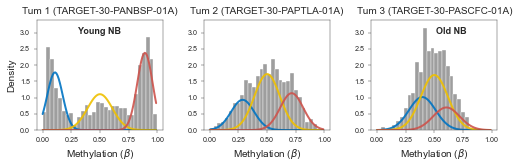

In [ ]:
## Plot beta value distriubtions for 3 example tumors

beta_values_Clock = pd.read_table(
    os.path.join(nbl_consts['official_indir'], 'TARGET', 'NBL.methyl.antiNonIterClustNotStuck_sites.tsv'),
    index_col=0)

sample_list = {
    # 'Tum1':'TARGET-30-PANUKV-01A',
    'Tum 1':'TARGET-30-PANBSP-01A',
    'Tum 2':'TARGET-30-PAPTLA-01A',
    'Tum 3':'TARGET-30-PASCFC-01A'
}

# Create plot axes
fig, axes = plt.subplots(1, len(sample_list), figsize=np.array(figsize) * [2.5, 1.2] * sf)
fig.tight_layout(pad=0.2)

# Color of each distribution in order (left -> right)
chosen_tumor_colors = [nbl_consts['palette_jco'][i] for i in [0, 1, 3]]

# X coordinates for curves
x_vals = np.linspace(0, 0.99, 100)

for i, tum_id in enumerate(sample_list):
    ax = axes[i]
    samp = sample_list[tum_id]
    patient = nbl_util.sampleToPatientID(samp)
    
    # Plot distribution
    sns.histplot(ax=ax, x=beta_values_Clock[samp], stat='density',
                 color=nbl_consts['palette_jco'][2],
                 bins=30, alpha=nbl_consts['opacity'],
                binrange=(0, 1))
    
    # Customize plot
    ax.set_title(f'{tum_id} ({samp})', fontsize=nbl_consts['labelfontsize'] * sf)
    ax.set_xlabel(r'Methylation ($\beta$)', fontsize=nbl_consts['labelfontsize'] * sf)
    if i == 0: # Only have y-axis label on left-most plot
        ax.set_ylabel('Density', fontsize=nbl_consts['labelfontsize'] * sf)
    else:
        ax.set_ylabel('')
    ax.tick_params(axis='both', labelsize=nbl_consts['ticksfontsize'] * sf, width=sf, length=8 * sf)

    # Weight of each of three distributions
    weight_list = gmm_results_target.loc[samp, ['psi[1].mean', 'psi[2].mean', 'psi[3].mean']]
    
    # Holds the max y-axis limit max
    y_max = float('-Inf')
    
    X_mean = gmm_results_target.loc[samp, 'X.mean']
    N_mean = gmm_results_target.loc[samp, 'N.mean']
    mu_list = [X_mean, 0.5, 1 - X_mean]
    sd_list = [sqrt(mu * (1 - mu) / N_mean) for mu in mu_list]
    
    # Plot each distribution
    for j in range(weight_list.shape[0]):

        # X and Y coords for curve
        y_vals = norm.pdf(x_vals, mu_list[j], sd_list[j]) * weight_list[j]
        
        # Plot curve
        ax.plot(x_vals, y_vals, lw=2, alpha=0.9,
                color=chosen_tumor_colors[j]
               )
        
        # Update max
        y_max = max(y_max, ax.get_ylim()[1])
    
#     y_vals_kernel = np.stack([norm.pdf(x_vals, mu_list[j], sd_list[j]) * weight_list[j] for j in range(weight_list.shape[0])], axis=0).sum(axis=0)
#     ax.plot(x_vals, y_vals_kernel, lw=1, alpha=0.9, color='gray')
    
# Align y-axis limits
for i in range(len(sample_list)):
    ax = axes[i]
    ax.set_ylim(0, y_max * 1.03)

for i, text, x_pos in zip([0, 2], ['Young NB', 'Old NB'], [0.5, 0.65]):
    axes[i].text(x_pos, y_max * 0.9,
            text,
                 # color='Black',
            ha="center", fontfamily='sans-serif', fontsize=0.9 * nbl_consts['labelfontsize'] * sf, fontweight='bold',
                 # alpha=nbl_consts['opacity']
           )

# Save figure
file_format = 'svg'
fig.savefig(os.path.join(figure_outdir, f'example_peak_decomp.{file_format}'), format=file_format, pad_inches=0.1)

# Tumor mitotic age distribution

## Histogram

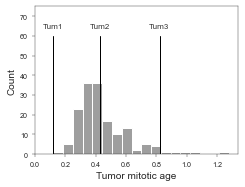

In [138]:
plot_data = clinical['TARGET'].loc[clinical['TARGET']['in_analysis_dataset'], 'phi']

# Create plot
fig, ax = plt.subplots(figsize=figsize * [1.3, 1.7] * sf)
sns.histplot(ax=ax, x=plot_data,
             color=nbl_consts['palette_jco'][2], alpha=nbl_consts['opacity'])

# Mark (with vertical lines) the c_beta values of three
#   example tumors from plot in the previous cell
line_color = 'black'
tumor_heights = [0.8, 0.8, 0.8]

x_0 = clinical['TARGET'].loc[nbl_util.sampleToPatientID(sample_list['Tum 1']), 'phi']
x_1 = clinical['TARGET'].loc[nbl_util.sampleToPatientID(sample_list['Tum 2']), 'phi']
x_2 = clinical['TARGET'].loc[nbl_util.sampleToPatientID(sample_list['Tum 3']), 'phi']

ax.axvline(x=x_0, ymax=tumor_heights[0], lw=2.5 * sf, color=line_color)
ax.axvline(x=x_1, ymax=tumor_heights[1], lw=2.5 * sf, color=line_color)
ax.axvline(x=x_2, ymax=tumor_heights[2], lw=2.5 * sf, color=line_color)

# Customize figure
ax.set_xlabel('Tumor mitotic age', fontsize=nbl_consts['labelfontsize']*sf)
ax.set_ylabel('Count', fontsize=nbl_consts['labelfontsize'] * sf)
ax.tick_params(axis='both', labelsize=nbl_consts['ticksfontsize'] * sf, width=sf, length=8 * sf)
ax.set_ylim(top=75)

# Widen plot a little
xlim = ax.get_xlim()
width = xlim[1] - xlim[0]
ax.set_xlim(left = xlim[0] - width/20)

# Annotate the vertical lines with text for all 3 tumors
y_height = ax.get_ylim()[1]

ax.text(x_0, (tumor_heights[0]+0.05)*y_height,
        'Tum1', color=line_color,
        ha="center", fontfamily='sans-serif', fontsize=0.8 * nbl_consts['labelfontsize'] * sf, alpha=nbl_consts['opacity']
       )
ax.text(x_1, (tumor_heights[1]+0.05)*y_height,
        'Tum2', color=line_color,
        ha="center", fontfamily='sans-serif', fontsize=0.8 * nbl_consts['labelfontsize'] * sf, alpha=nbl_consts['opacity']
       )
ax.text(x_2-0.005, (tumor_heights[2]+0.05)*y_height,
        'Tum3', color=line_color,
        ha="center", fontfamily='sans-serif', fontsize=0.8 * nbl_consts['labelfontsize'] * sf, alpha=nbl_consts['opacity']
       )

# Save figure
file_format = 'svg'
fig.savefig(os.path.join(figure_outdir, f'mitotic_age_distribution.{file_format}'), format=file_format, pad_inches=0.1)

## Beeswarm

In [139]:
sample_list_inverse = dict(map(lambda x:x[::-1], list(sample_list.items())))
clinical['TARGET']['TumLabeled'] = clinical['TARGET']['sampleID'].map(sample_list_inverse).fillna('Others')

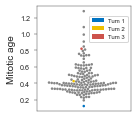

In [142]:
# Create plot
fig, ax = plt.subplots(figsize=figsize * [1 * 0.6, 1.2] * sf)
point_size = 16

#########################################
########### Mitotic age (phi) ###########
#########################################

jco = nbl_consts['palette_jco']
color_dict = dict(zip(['Others', 'Tum 1', 'Tum 2', 'Tum 3'], [jco[2], jco[0], jco[1], jco[3]]))

sns.swarmplot(
    ax=ax,
    data=iad(clinical['TARGET']),
    y='phi',
    palette=color_dict,
    hue='TumLabeled',
    legend=False,
    s=point_size * sf**2
)

# Customize figure
ax.set_xlabel('')
ax.set_ylabel('Mitotic age', fontsize=nbl_consts['labelfontsize'] * sf)
ax.set_xticks([])
ax.tick_params(axis='y', labelsize=nbl_consts['ticksfontsize'] * sf, width=sf, length=8 * sf)

# Legend
patches = [
    mpatches.Patch(color=color_dict[group], label=group, alpha=1, lw=0)
    for group in [f'Tum {i}' for i in range(1, 4)]
]

plots_x, plots_y = ax.get_position().get_points()[1]
fig.legend(handles=patches,
           loc='upper right',
           bbox_to_anchor=(plots_x, plots_y * 0.95),
           fontsize= 0.6 * nbl_consts['labelfontsize'] * sf
          )

# Save figure
fig.savefig(os.path.join(figure_outdir, 'mitotic_age_divisions_beeswarm.svg'), format='svg', pad_inches=0.1)

# Covariate Analysis

<Axes: xlabel='gender', ylabel='Tumor mitotic age'>

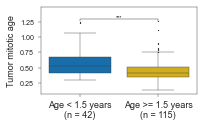

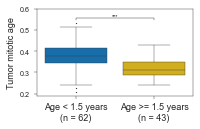

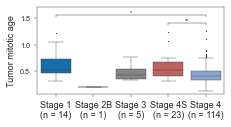

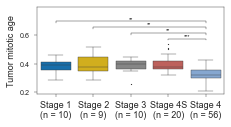

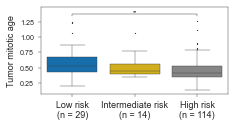

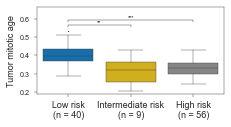

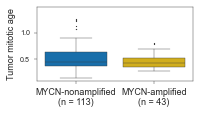

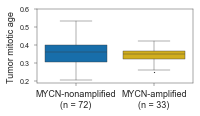

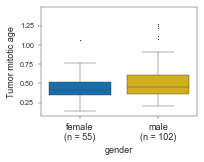

In [50]:
nbl_util.saveBoxPlotNew(clinical['TARGET'], 'Age >= 1.5', restrict=True,
                   var_y='phi', outfile=True, title=False, signif_bar_heights = 0.02,
                   palette=nbl_consts['palette_jco'], xlabel='', ylabel='Tumor mitotic age',
                       outdir=covar_path_outdir, file_format='svg',
                   figsize=figsize, labelfontsize=nbl_consts['labelfontsize'] * 0.9, ticksfontsize=nbl_consts['ticksfontsize'], sf=sf, linewidth=nbl_consts['linewidth'], fliersize=nbl_consts['fliersize'])

nbl_util.saveBoxPlotNew(clinical['Henrich'], 'age at diagnosis', restrict=True,
                   var_y='phi', outfile=True, title=False, signif_bar_heights = 0.02,
                   palette=nbl_consts['palette_jco'], xlabel='', ylabel='Tumor mitotic age',
                       outdir=covar_path_outdir, file_format='svg',
                   figsize=figsize, labelfontsize=nbl_consts['labelfontsize'] * 0.9, ticksfontsize=nbl_consts['ticksfontsize'], sf=sf, linewidth=nbl_consts['linewidth'], fliersize=nbl_consts['fliersize'])

nbl_util.saveBoxPlotNew(clinical['TARGET'], 'inss_stage', restrict=True,
                   var_y='phi', outfile=True, title=False, signif_bar_heights = 0.15,
                   palette=nbl_consts['palette_jco'], xlabel='', ylabel='Tumor mitotic age', file_format='svg',
                       outdir=covar_path_outdir, use_groups=['Stage 1', 'Stage 2B', 'Stage 3', 'Stage 4S', 'Stage 4'],
                   figsize=figsize * [1.2, 1], labelfontsize=nbl_consts['labelfontsize'] * 0.9, ticksfontsize=nbl_consts['ticksfontsize'], sf=sf, linewidth=nbl_consts['linewidth'], fliersize=nbl_consts['fliersize'])

nbl_util.saveBoxPlotNew(clinical['Henrich'], 'inss stage', restrict=True,
                   var_y='phi', outfile=True, title=False, signif_bar_heights = 0.04,
                   palette=nbl_consts['palette_jco'], xlabel='', ylabel='Tumor mitotic age', file_format='svg',
                       outdir=covar_path_outdir, use_groups=['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4S', 'Stage 4'],
                   figsize=figsize * [1.2, 1], labelfontsize=nbl_consts['labelfontsize'] * 0.9, ticksfontsize=nbl_consts['ticksfontsize'], sf=sf, linewidth=nbl_consts['linewidth'], fliersize=nbl_consts['fliersize'])

nbl_util.saveBoxPlotNew(clinical['TARGET'], 'cog_neuroblastoma_risk_group', restrict=True,
                   var_y='phi', outfile=True, title=False, signif_bar_heights = 0.1,
                   palette=nbl_consts['palette_jco'], xlabel='', ylabel='Tumor mitotic age', file_format='svg',
                       outdir=covar_path_outdir, use_groups=["Low risk", "Intermediate risk", "High risk"],
                   figsize=figsize * [1.2, 1], labelfontsize=nbl_consts['labelfontsize'] * 0.9, ticksfontsize=nbl_consts['ticksfontsize'], sf=sf, linewidth=nbl_consts['linewidth'], fliersize=nbl_consts['fliersize'])

nbl_util.saveBoxPlotNew(clinical['Henrich'], 'current risk category', restrict=True,
                   var_y='phi', outfile=True, title=False, signif_bar_heights = 0.03,
                   palette=nbl_consts['palette_jco'], xlabel='', ylabel='Tumor mitotic age', file_format='svg',
                       outdir=covar_path_outdir, use_groups=["Low risk", "Intermediate risk", "High risk"],
                   figsize=figsize * [1.2, 1], labelfontsize=nbl_consts['labelfontsize'] * 0.9, ticksfontsize=nbl_consts['ticksfontsize'], sf=sf, linewidth=nbl_consts['linewidth'], fliersize=nbl_consts['fliersize'])

nbl_util.saveBoxPlotNew(clinical['TARGET'], 'MYCN status', restrict=True,
                   var_y='phi', outfile=True, title=False, signif_bar_heights = 0.1,
                   palette=nbl_consts['palette_jco'], xlabel='', ylabel='Tumor mitotic age', file_format='svg',
                       outdir=covar_path_outdir, use_groups=['MYCN-nonamplified', 'MYCN-amplified'],
                   figsize=figsize * [1, 0.85], labelfontsize=nbl_consts['labelfontsize'] * 0.9, ticksfontsize=nbl_consts['ticksfontsize'], sf=sf, linewidth=nbl_consts['linewidth'], fliersize=nbl_consts['fliersize'])

nbl_util.saveBoxPlotNew(clinical['Henrich'], 'mycn status', restrict=True,
                   var_y='phi', outfile=True, title=False, signif_bar_heights = 0.023,
                   palette=nbl_consts['palette_jco'], xlabel='', ylabel='Tumor mitotic age', file_format='svg',
                       outdir=covar_path_outdir, use_groups=['MYCN-nonamplified', 'MYCN-amplified'],
                   figsize=figsize * [1, 0.85], labelfontsize=nbl_consts['labelfontsize'] * 0.9, ticksfontsize=nbl_consts['ticksfontsize'], sf=sf, linewidth=nbl_consts['linewidth'], fliersize=nbl_consts['fliersize'])

nbl_util.saveBoxPlotNew(clinical['TARGET'], 'gender', restrict=True,
                   var_y='phi', outfile=False, title=False, signif_bar_heights = 0.02,
                   palette=nbl_consts['palette_jco'], xlabel='gender', ylabel='Tumor mitotic age', file_format='svg',
                   figsize=np.array([7, 5]), labelfontsize=nbl_consts['labelfontsize'] * 0.9, ticksfontsize=nbl_consts['ticksfontsize'], sf=sf, linewidth=nbl_consts['linewidth'], fliersize=nbl_consts['fliersize'])

## Estimate calendar ages

In [29]:
MIN_DAYS_BEFORE_BIRTH = 40 * 7

TARGET_ssGSEA_scores = pd.read_table(os.path.join(proj_dir_target, 'TARGET_ssGSEA_scores_all.tsv'))

In [30]:
clinical['TARGET'] = clinical['TARGET'].merge(TARGET_ssGSEA_scores, left_on='sampleID', right_index=True)
c = clinical['TARGET']
assert not c.loc[c['in_analysis_dataset'], 'proliferation_score'].isna().any()

clinical['TARGET']['phi_div_alpha'] = clinical['TARGET']['phi'] / clinical['TARGET']['proliferation_score']

### Mean method

In [31]:
dataset = 'TARGET'

cl = iad(clinical[dataset])

age_day_limit = 80
young_tumors = cl.index[cl['age_at_diagnosis'] <= age_day_limit]

print(f'Using {young_tumors.shape[0]} tumors to estimate k * mu')

approx_avg_calAge = clinical[dataset].loc[young_tumors]['age_at_diagnosis'].mean() + 6*30
k_mu_meanmethod = clinical[dataset].loc[young_tumors]['phi_div_alpha'].mean() / approx_avg_calAge

clinical['TARGET']['calendar_age_meanmethod'] = clinical['TARGET']['phi_div_alpha'] / k_mu_meanmethod

Using 26 tumors to estimate k * mu


In [33]:
iad(clinical['TARGET']).loc[young_tumors, 'calendar_age_meanmethod'].mean()

217.03846153846155

## Waterfall plot

In [34]:
clinical['TARGET']['Stage 4'] = (clinical['TARGET']['inss_stage'] == 'Stage 4').map(lambda x:'Stage 4' if x else 'Stage 1, 3, or 4S')
clinical['TARGET']['calendar_age_years'] = clinical['TARGET']['calendar_age_meanmethod'] / 365

PREGNANCY_LENGTH = 40 * 7

In [35]:
color_var = 'Stage 4'
color_dict = dict(zip(clinical['TARGET'][color_var].unique(), [nbl_consts['palette_jco'][3], nbl_consts['palette_jco'][4]]))

def swimmersPlot(fig, ax, tumors_chosen, legend=True, xlabel=True, xlim_left=-1.5, y_extra=4):
    tumors_ordered = clinical['TARGET'].loc[tumors_chosen].sort_values('Age').index

    for i, tum in enumerate(tumors_ordered):
        x_points = [clinical['TARGET'].loc[tum, 'Age'] - clinical['TARGET'].loc[tum, 'calendar_age_years'], clinical['TARGET'].loc[tum, 'Age']]
        y_points = [i, i]
        color = color_dict[clinical['TARGET'].loc[tum, color_var]]

        # Plot the circle on the left side
        ax.plot(x_points[0], y_points[0], 'o', markersize=4*sf, color=color)  # green circle

        shrink = 0
        arrow = mpatches.FancyArrowPatch((x_points[0], y_points[0]), (x_points[1], y_points[1]),
                                         arrowstyle='-|>', color=color,
                                         linewidth=2*sf, mutation_scale=12*sf,
                                         shrinkA=shrink, shrinkB=shrink)
        ax.add_patch(arrow)    

    if legend:
        # Main legend
        patches_main = [Line2D([0], [0], color=color_dict[group], linewidth=2*sf, label=group)
                   for group in color_dict.keys()]
        
        # Line/shading legend
        patches = [
            Line2D([0], [0],
                   color=nbl_consts['palette_jco'][2],
                   linestyle='--', linewidth=3*sf,
                   label='Conception'),
            mpatches.Patch(color=nbl_consts['palette_jco'][2], alpha=0.2, lw=0,
                           # label='Screening period'
                           label='Infancy'
                          )
        ][::-1]
        patches.extend(patches_main)
        
        fig.legend(handles=patches[::-1],
                   loc='upper right',
                   bbox_to_anchor = (0.9 * 0.99, 0.88 * 0.275),
                   fontsize= 1.2 * nbl_consts['labelfontsize'] * sf
                  )

    if xlabel:
        ax.set_xlabel('Patient age (years)', fontsize= 1.6 * nbl_consts['labelfontsize']*sf)
    ax.tick_params(axis='y', which='both', left=False, labelleft=False)  
    ax.tick_params(axis='x', labelsize= 1.2 * nbl_consts['ticksfontsize'] * sf, width=sf, length=8 * sf)

    ax.axvline(x= - PREGNANCY_LENGTH / 365,
               color=nbl_consts['palette_jco'][2], linestyle='--', linewidth=3*sf)


    ax.set_xlim(left=xlim_left, right=clinical['TARGET'].loc[tumors_chosen, 'Age'].max())

    bottom = -y_extra
    top = len(tumors_ordered) + y_extra
    ax.set_ylim(bottom, top)
    ax.fill([0, 1, 1, 0], [bottom, bottom, top, top],
            color=nbl_consts['palette_jco'][2], alpha=0.2, lw=0)

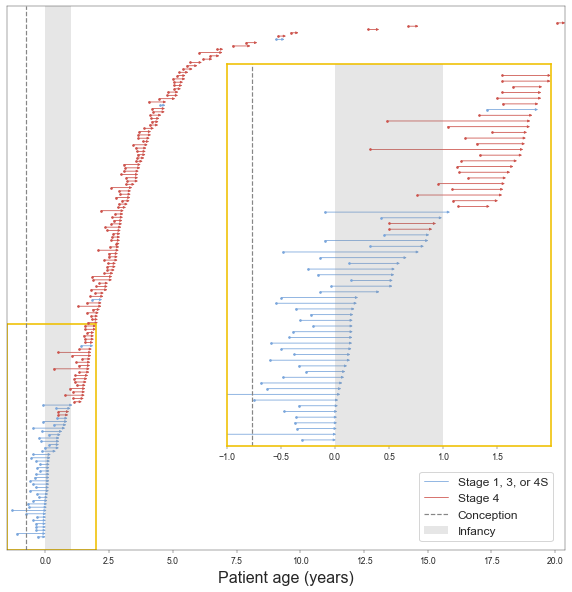

In [36]:
all_patients = iad(clinical['TARGET']).index

fig, ax = plt.subplots(figsize=np.array((25, 25)) * sf)
xlim_left = -1.5
y_extra = 4
swimmersPlot(fig, ax, all_patients, xlim_left=xlim_left, y_extra=y_extra)

# Overlay blown-up plot
years_thresh = 2.0
ax2 = fig.add_axes([0.43, 0.27, 0.45, 0.53])
patients_younger_2_years = clinical['TARGET'].index[clinical['TARGET']['in_analysis_dataset'] & (clinical['TARGET']['Age'] <= years_thresh)]
swimmersPlot(fig, ax2, patients_younger_2_years, legend=False, xlabel=False, xlim_left=-1, y_extra=1)
for spine in ax2.spines.values():
    spine.set_edgecolor(nbl_consts['palette_jco'][1])
    spine.set_linewidth(4 * sf)

ax.add_patch(
    mpatches.Rectangle((years_thresh, -y_extra), width=-years_thresh + xlim_left, height=y_extra + patients_younger_2_years.shape[0] - 0.5,
                         linewidth=4 * sf, edgecolor=nbl_consts['palette_jco'][1], facecolor='none')
)

# Save figure
file_format = 'svg'
fig.savefig(os.path.join(figure_outdir, f'swimmer_plot.meanmethod.{file_format}'), format=file_format, pad_inches=0.1)

## Statistics

In [121]:
cl = iad(clinical['TARGET'])
cl['Initiation Age'] = cl['Age'] - cl['calendar_age_years']
cl['Initiated after 1 year'] = cl['Initiation Age'] > 1
cl['Good outcome stage'] = cl['inss_stage'] != 'Stage 4'

### (i)

In [122]:
cl_after15 = iad(cl).loc[cl['Age'] > 1.5]
print('Tumors detected after 1.5 years of age\n')

print(f'Min age at tumor initiation: {cl_after15["Initiation Age"].min():.2f} yrs')
print(f'# tumors total: {cl_after15["Initiation Age"].shape[0]}')
print(f'# tumors initiated after 1 year of age: {cl_after15["Initiated after 1 year"].sum()}')
print(f'Percent of tumors initiated after 1 year of age: {cl_after15["Initiated after 1 year"].mean() * 100:.2f}')

Tumors detected after 1.5 years of age

Min age at tumor initiation: 1.21 yrs
# tumors total: 115
# tumors initiated after 1 year of age: 115
Percent of tumors initiated after 1 year of age: 100.00


### (ii)

In [123]:
iad(cl)['inss_stage'].value_counts()

Stage 4     114
Stage 4S     23
Stage 1      14
Stage 3       5
Stage 2B      1
Name: inss_stage, dtype: int64

In [124]:
display(cl.groupby('Good outcome stage')['Initiated after 1 year'].agg(['sum', 'mean']))

print('Good outcome stage counts:')
display(cl['Good outcome stage'].value_counts())

,sum,mean
Good outcome stage,,
False,112,0.982456
True,4,0.093023


Good outcome stage counts:


False    114
True      43
Name: Good outcome stage, dtype: int64

In [125]:
print(format(39/43, '.1%'))

90.7%


### (iii)

In [126]:
print('Mean sojourn times (calendar age in days)\n')

display(cl.groupby('inss_stage')['calendar_age'].agg(['mean', 'min', 'max']))
print()
display(cl.groupby('Good outcome stage')['calendar_age'].agg(['mean', 'min', 'max']))

from scipy.stats import ttest_ind
ttest_res = ttest_ind(
    cl.loc[cl['Good outcome stage'], 'calendar_age'],
    cl.loc[~cl['Good outcome stage'], 'calendar_age']
)
print(f'T-test, P = {ttest_res.pvalue:.0e}')

Mean sojourn times (calendar age in days)



,mean,min,max
inss_stage,,,
Stage 1,133.192514,78.212849,260.449682
Stage 2B,42.569565,42.569565,42.569565
Stage 3,86.928143,67.916968,110.488174
Stage 4,90.139955,26.104460,318.365456
Stage 4S,122.361788,66.738783,195.870910


,mean,min,max
Good outcome stage,,,
False,90.139955,26.104460,318.365456
True,119.912246,42.569565,260.449682


T-test, P = 7e-05


# Clinical supplements

In [285]:
clinical_survival = pd.read_table(os.path.join(nbl_consts['official_indir'], 'TARGET', 'clinical.annotated.survival.tsv'), index_col=0)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/danielmonyak/Library/CloudStorage/Box-Box/PROJECT 06023: MolClocks/Neuroblastoma_Paper/Datasets/TARGET/clinical.annotated.survival.tsv'

In [286]:
supp1 = pd.read_excel('/Users/danielmonyak/Library/CloudStorage/Box-Box/PROJECT 06023: MolClocks/Neuroblastoma_Paper/Datasets/TARGET/gdc_data/TARGET-NBL/Clinical/Clinical_Supplement/cdb0d02c-43d0-4d50-931d-ec2dbdf71a24/TARGET_NBL_ClinicalData_Validation_20230322.xlsx',
                     sheet_name='Clinical Data', index_col=0)
supp2 = pd.read_excel('/Users/danielmonyak/Library/CloudStorage/Box-Box/PROJECT 06023: MolClocks/Neuroblastoma_Paper/Datasets/TARGET/gdc_data/TARGET-NBL/Clinical/Clinical_Supplement/f5bfc8a5-b903-4418-b633-62234388a635/TARGET_NBL_ClinicalData_Discovery_20230523.xlsx',
                     sheet_name='Clinical Data', index_col=0)
# So all of the samples with methylation data are on supp2
supp2_meth = supp2.loc[clinical['TARGET'].index]

/Users/danielmonyak/miniforge3/lib/python3.9/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")
/Users/danielmonyak/miniforge3/lib/python3.9/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


## Exlore sample set

In [208]:
print(supp1.shape)
print(supp2.shape)

print(np.intersect1d(supp1.index, supp2.index).shape)
print(np.unique(np.concatenate([supp1.index, supp2.index])).shape) # 842 is the total number of TARGET-NBL patients
print((supp1.columns == supp2.columns).all())

(499, 30)
(343, 30)
(0,)
(842,)
True


In [209]:
print(np.intersect1d(clinical['TARGET'].index, supp1.index).shape)
print(np.intersect1d(clinical['TARGET'].index, supp2.index).shape)

(0,)
(157,)


## Percent tumor

In [210]:
supp2_meth['Percent Tumor'].isna().sum()

36

In [287]:
display(supp2_meth['Percent Tumor'].value_counts())
# Use lower bound when a range is given
supp2_meth['Percent Tumor Min'] = supp2_meth['Percent Tumor'].map(lambda x: x if type(x) is not str else float(x.split('-')[0]))
supp2_meth['Percent Necrosis Max'] = supp2_meth['Percent Necrosis'].map(lambda x: x if type(x) is not str else float(x.split('-')[0]))

90       34
80       17
60       10
40       10
70        7
75        4
10        4
95        3
80-90     3
100       3
85        3
50        3
30-40     3
0         2
65        2
5         2
30        2
20        2
35        1
85-90     1
90-95     1
70-80     1
97-98     1
55        1
10-20     1
Name: Percent Tumor, dtype: int64

Text(0.5, 1.0, 'n = 169\nmean = 67.6\nmedian = 80.0')

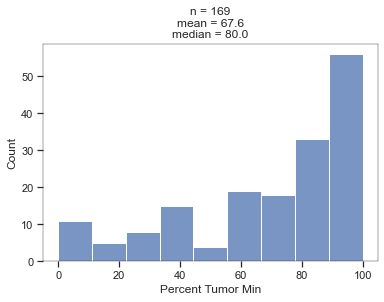

In [152]:
vals = supp2_meth['Percent Tumor Min']
vals = vals[~vals.isna()]
sns.histplot(vals)
plt.title(f'n = {len(vals)}\nmean = {np.mean(vals):.1f}\nmedian = {np.median(vals)}')

In [153]:
np.mean(vals > 50)

0.7514792899408284

In [154]:
supp2_meth['Percent Tumor Min'].describe()

count    169.000000
mean      67.615385
std       26.091414
min        0.000000
25%       55.000000
50%       80.000000
75%       90.000000
max      100.000000
Name: Percent Tumor Min, dtype: float64

In [155]:
print((supp2_meth['Percent Tumor Min'] < 40).sum())

25


44
213
144
126
107


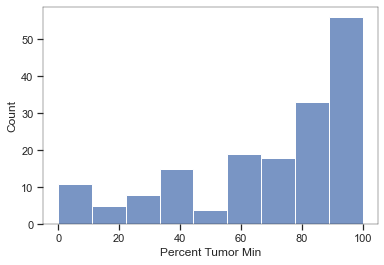

In [156]:
print(supp2_meth['Percent Tumor Min'].isna().sum())
sns.histplot(supp2_meth['Percent Tumor Min'])

print(supp2_meth.shape[0])
print((supp2_meth['Percent Tumor Min'] >= 40).sum())
print((supp2_meth['Percent Tumor Min'] >= 60).sum())
print((supp2_meth['Percent Tumor Min'] >= 70).sum())

<Axes: xlabel='Percent Necrosis Max', ylabel='Count'>

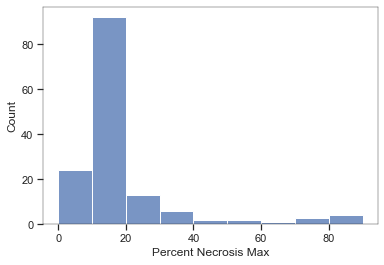

In [157]:
sns.histplot(supp2_meth['Percent Necrosis Max'])

## Concordance of clinicopathological data

In [158]:
a.rename(columns=lambda x:x.lower())

NameError: name 'a' is not defined

In [368]:
def concordanceTable(var_clinical, var_supp2):
    return pd.concat([
        clinical['TARGET'][var_clinical].rename('clinical'),
        supp2_meth[var_supp2].rename('supp2')
    ], axis=1).groupby('clinical')['supp2'].value_counts().unstack().fillna(0).astype(int).map(lambda x:str(x) if x > 0 else '').rename(index=lambda x:x.lower()).rename(columns=lambda x:x.lower()).sort_index(axis=0).sort_index(axis=1)

display(concordanceTable('race', 'Race'))
display(concordanceTable('inss_stage', 'INSS Stage'))
display(concordanceTable('inpc_grade', 'Grade'))
display(concordanceTable('cog_neuroblastoma_risk_group', 'COG Risk Group'))
display(concordanceTable('gender', 'Gender'))

(clinical['TARGET']['age_at_diagnosis'] == supp2_meth['Age at Diagnosis in Days']).all()

supp2,asian,black or african american,native hawaiian or other pacific islander,unknown,white
clinical,,,,,
asian,2,,,,
black or african american,,30,,,
native hawaiian or other pacific islander,,,3,,
unknown,,,,19,
white,,,,,159


supp2,stage 1,stage 2b,stage 3,stage 4,stage 4s
clinical,,,,,
stage 1,15,,,,
stage 2b,,1,,,
stage 3,,,6,,
stage 4,,,,167,
stage 4s,,,,,24


supp2,differentiating,undifferentiated or poorly differentiated,unknown
clinical,,,
differentiating,13,,
undifferentiated or poorly differentiated,,162,
unknown,,,38


supp2,high risk,intermediate risk,low risk
clinical,,,
high risk,168,,
intermediate risk,,14,
low risk,,,31


supp2,female,male
clinical,,
female,85,
male,,128


True

## Relapse data

In [376]:
has_relapse = ~supp2_meth['Site of Relapse'].isna()
print(has_relapse.sum())
print(clinical['TARGET']['progression_or_recurrence'].unique())

88
[nan]


In [377]:
has_relapse

submitter_id
TARGET-30-PANWRR     True
TARGET-30-PARETE     True
TARGET-30-PARSRJ     True
TARGET-30-PATGWT     True
TARGET-30-PASLGS    False
                    ...  
TARGET-30-PALZRG     True
TARGET-30-PASPBZ    False
TARGET-30-PASMDM    False
TARGET-30-PARNNC     True
TARGET-30-PARZHA    False
Name: Site of Relapse, Length: 213, dtype: bool

## Concordance of survival data

In [322]:
supp2_meth

,Gender,Race,Ethnicity,Age at Diagnosis in Days,First Event,Event Free Survival Time in Days,Vital Status,Overall Survival Time in Days,Year of Diagnosis,Year of Last Follow Up,...,COG Risk Group,Percent Tumor,Percent Necrosis,Percent Tumor v/s Stroma,Sites of Disease Involvement,Site of Relapse,Relapse Percent Tumor,Relapse Percent Necrosis,Relapse Percent Tumor v/s Stroma,Percent Tumor Min
submitter_id,,,,,,,,,,,,,,,,,,,,,
TARGET-30-PANWRR,Male,White,Not Hispanic or Latino,2937,Progression,267.0,Dead,345.0,2005,2006.0,...,High Risk,NaN,NaN,NaN,NaN,Lymph Nodes,NaN,NaN,NaN,NaN
TARGET-30-PARETE,Male,White,Not Hispanic or Latino,686,Progression,241.0,Dead,261.0,2007,2008.0,...,High Risk,40,30,40/60,NaN,Primary Site; Bone Marrow; Other Metastatic Sites,NaN,NaN,NaN,40.0
TARGET-30-PARSRJ,Male,White,Not Hispanic or Latino,1905,Relapse,1329.0,Alive,3225.0,2007,2016.0,...,High Risk,5,90,5/95,NaN,Bone,NaN,NaN,NaN,5.0
TARGET-30-PATGWT,Male,Black or African American,Not Hispanic or Latino,591,Relapse,727.0,Dead,928.0,2010,2012.0,...,High Risk,50,10,50/50,NaN,Bone; Lymph Nodes,NaN,NaN,NaN,50.0
TARGET-30-PASLGS,Male,Unknown,Not Hispanic or Latino,1218,Event,546.0,Dead,830.0,2009,2011.0,...,High Risk,80,10,80/20,NaN,NaN,NaN,NaN,NaN,80.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TARGET-30-PALZRG,Female,White,Not Hispanic or Latino,577,Relapse,422.0,Dead,580.0,2002,2004.0,...,High Risk,75,25,90/10,NaN,"Other, specify: Lobular, large suprarenal mass...",NaN,NaN,NaN,75.0
TARGET-30-PASPBZ,Male,Black or African American,Not Hispanic or Latino,62,Censored,3434.0,Alive,3434.0,2009,2018.0,...,Intermediate Risk,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80.0
TARGET-30-PASMDM,Male,White,Not Hispanic or Latino,25,Censored,1324.0,Alive,1324.0,2009,2012.0,...,Low Risk,40,10,40/60,NaN,NaN,NaN,NaN,NaN,40.0


## MYC amplification status

In [288]:
clinical['TARGET'].drop('MYCN status', axis=1, inplace=True, errors='ignore')
clinical['TARGET'] = clinical['TARGET'].merge(supp2_meth['MYCN status'], left_index=True, right_index=True)
clinical['TARGET']['MYCN status'] = clinical['TARGET']['MYCN status'].map({'Amplified':'MYCN-amplified', 'Not Amplified':'MYCN-nonamplified'})
clinical['TARGET'].to_csv(os.path.join(proj_dir, 'clinical.TARGET.annotated.withMYCN.tsv'), sep='\t')

clinical['TARGET'].name = 'Discovery'

<Axes: ylabel='Tumor mitotic age'>

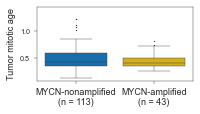

In [289]:
nbl_util.saveBoxPlotNew(clinical['TARGET'], 'MYCN status', restrict=True,
                   var_y='phi', outfile=True, title=False, signif_bar_heights = 0.1,
                   palette=nbl_consts['palette_jco'], xlabel='', ylabel='Tumor mitotic age', file_format='svg',
                       outdir=covar_path_outdir, use_groups=['MYCN-nonamplified', 'MYCN-amplified'],
                   figsize=figsize * [1, 0.85], labelfontsize=nbl_consts['labelfontsize'] * 0.9, ticksfontsize=nbl_consts['ticksfontsize'], sf=sf, linewidth=nbl_consts['linewidth'], fliersize=nbl_consts['fliersize'])

In [ ]:
cols = gmm_results_target.columns
neff_cols = cols[cols.str.endswith('n_eff')]
neff_df = gmm_results_target[neff_cols].drop('mu_middle.n_eff', axis=1)

In [ ]:
cols = gmm_results_target.columns
rhat_cols = cols[cols.str.endswith('Rhat')]
rhat_df = gmm_results_target[rhat_cols].drop('mu_middle.Rhat', axis=1)

<Axes: ylabel='Count'>

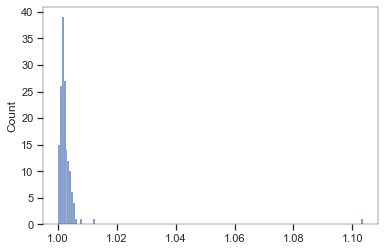

In [242]:
sns.histplot(rhat_df.max(axis=1))

<Axes: ylabel='Count'>

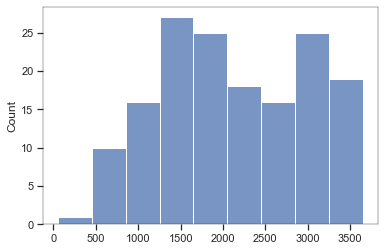

In [237]:
sns.histplot(neff_df.min(axis=1))

In [247]:
clinical['TARGET']['phi_old'] = phi_old.loc[clinical['TARGET'].index]

<Axes: xlabel='phi', ylabel='phi_old'>

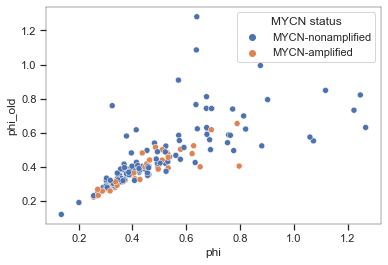

In [252]:
sns.scatterplot(
    data=clinical['TARGET'],
    x='phi',
    y='phi_old',
    hue='MYCN status'
)

<Axes: xlabel='MYCN status', ylabel='phi'>

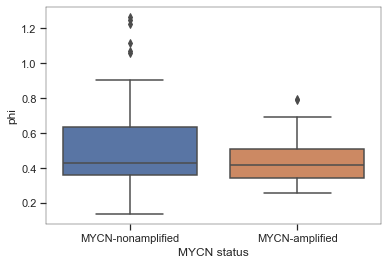

In [251]:
sns.boxplot(
    data=clinical['TARGET'],
    y='phi',
    x='MYCN status'
)

# Covariate Analysis with calendar age

<Axes: title={'center': 'Discovery'}, ylabel='Tumor age (years)'>

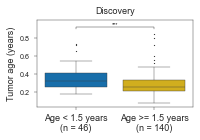

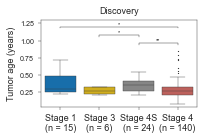

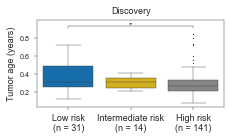

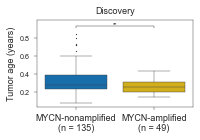

In [ ]:
nbl_util.saveBoxPlotNew(clinical['TARGET'], 'Age >= 1.5', restrict=True,
                   var_y='calendar_age_years', outfile=True, title=True, signif_bar_heights = 0.07,
                   palette=nbl_consts['palette_jco'], xlabel='', ylabel='Tumor age (years)',
                       outdir=covar_path_outdir,
                   figsize=figsize, labelfontsize=nbl_consts['labelfontsize'] * 0.9, ticksfontsize=nbl_consts['ticksfontsize'], sf=sf, linewidth=nbl_consts['linewidth'], fliersize=nbl_consts['fliersize'])

nbl_util.saveBoxPlotNew(clinical['TARGET'], 'inss_stage', restrict=True,
                   var_y='calendar_age_years', outfile=True, title=True, signif_bar_heights = 0.12,
                   palette=nbl_consts['palette_jco'], xlabel='', ylabel='Tumor age (years)',
                       outdir=covar_path_outdir, use_groups=['Stage 1', 'Stage 3', 'Stage 4S', 'Stage 4'],
                   figsize=figsize, labelfontsize=nbl_consts['labelfontsize'] * 0.9, ticksfontsize=nbl_consts['ticksfontsize'], sf=sf, linewidth=nbl_consts['linewidth'], fliersize=nbl_consts['fliersize'])

nbl_util.saveBoxPlotNew(clinical['TARGET'], 'cog_neuroblastoma_risk_group', restrict=True,
                   var_y='calendar_age_years', outfile=True, title=True, signif_bar_heights = 0.08,
                   palette=nbl_consts['palette_jco'], xlabel='', ylabel='Tumor age (years)',
                       outdir=covar_path_outdir, use_groups=["Low risk", "Intermediate risk", "High risk"],
                   figsize=figsize * [1.2, 1], labelfontsize=nbl_consts['labelfontsize'] * 0.9, ticksfontsize=nbl_consts['ticksfontsize'], sf=sf, linewidth=nbl_consts['linewidth'], fliersize=nbl_consts['fliersize'])

nbl_util.saveBoxPlotNew(clinical['TARGET'], 'MYCN status', restrict=True,
                   var_y='calendar_age_years', outfile=True, title=True, signif_bar_heights = 0.08,
                   palette=nbl_consts['palette_jco'], xlabel='', ylabel='Tumor age (years)',
                       outdir=covar_path_outdir, use_groups=['MYCN-nonamplified', 'MYCN-amplified'],
                   figsize=figsize, labelfontsize=nbl_consts['labelfontsize'] * 0.9, ticksfontsize=nbl_consts['ticksfontsize'], sf=sf, linewidth=nbl_consts['linewidth'], fliersize=nbl_consts['fliersize'])

# Summary table

In [4]:
from EpiClockNBL.analysis import clinical_table
clinical_table.pipeline()